In [1]:
import numpy as np
from math import *
import matplotlib.pyplot as plt
import scipy.stats as stats
import scipy

# 4) Chaînes de Markov 

Les chaînes de Markov, c'est un sujet qui tombe assez souvent à l'oral, alors même si ça peut amener à des choses très différentes de ce qui va suivre, il est tout de même bon de connaître les bases dans un cadre ""simple"". Dans la suite, on considère une chaîne de Markov $(X_k)_{k \ge 1 }$ de matrice de transition $P$ sur un espace d'états au plus dénombrable. 

## 4.1) Simuler une trajectoire 

Le programme suivant permet de simuler la trajectoire de notre chaîne de Markov, à partir de sa matrice de transition $P$, de son état initial et du nombre de pas que l'on veut dans le cas où l'espace d'états est fini. Ici, on met l'espace d'états en bijection avec $[0,len(P)-1]$. Si le cardinal de l'espace d'états est infini $(\mathbb Z$ par exemple), ou que la matrice de transition est fastidieuse à coder, il faut faire autrement ! (par exemple en utilisant une relation de récurrence, cf TP 4). 

In [4]:
def trajectoire_Markov(n,P,x0):
    X=np.zeros(n,dtype=int) #on indique que X contiendra seulement des entiers.
    X[0]=x0
    for k in range(n-1):
        X[k+1]=np.random.choice(a=range(len(P)), p=P[X[k],:])
        # Les états sont numérotés de 0 à len(P)-1
    return X

P=np.array([[1/3, 1/3, 1/6, 1/6], [0, 1/2, 0, 1/2], [1/4, 1/4, 1/4, 1/4], [1/3, 1/3, 1/3, 0]])

X=trajectoire_Markov(100,P,0)
print(X)

[0 0 0 1 1 1 3 0 1 3 1 1 1 3 0 0 1 1 1 1 3 2 1 3 1 1 3 0 1 1 3 0 3 0 0 1 1
 1 3 2 3 2 0 2 3 1 3 2 1 3 0 2 2 2 1 1 1 1 1 1 3 2 1 1 1 1 1 3 1 1 1 3 0 0
 0 2 3 1 1 3 1 1 1 3 1 1 1 3 2 1 1 3 0 2 2 3 1 1 1 3]


## 4.2) Calculer une proba invariante (3 méthodes)

### 4.2.1) Première méthode : avec la définition et grâce à l'algèbre linéaire 

Une probabilité invariante $\pi$ de la chaîne est une probabilité qui vérifie l'équation suivante : 
$$\pi P = \pi,$$
autrement dit, $\pi$ est un vecteur propre de la transposée de $P$ pour la valeur propre $1$. 

Pour toute la suite, on se donne par exemple la matrice de transition suivante (matrice de l'exo 2 du TP 4): 
$$\begin{bmatrix}
0.9 & 0.05 & 0.05 \\
0.7 & 0    & 0.3  \\
0.8 & 0    & 0.2
\end{bmatrix}. $$
La chaîne correspondante est irréductible, et ainsi tous les états sont de même nature. Etant donné que l'espace d'états est fini, les états sont tous réccurents positifs. Le coefficient $P_{1,1}$ est non nul (i.e on peut boucler sur $1$), et puisque il n'y a qu'une seule classe d'équivalence, la chaîne est apériodique.

Ici, puisque l'espace d'états est de cardinal fini, on sait qu'il existe une proba invariante. Les théorèmes généraux (i.e dans le cas au plus dénombrable) nous disent que si $P$ est irréductible, alors la chaîne admet au plus une proba invariante, et que dans ce cas, il y a équivalence entre existence d'une unique proba invariante et le fait que tous les états soient réccurents positifs (et donc avec le fait qu'il existe un état réccurent positif, ce qui est équivalent par irréductibilité). 

Dans notre cas, on a donc existence d'une unique proba invariante, et nous allons pour l'instant l'obtenir grâce à l'algèbre linéaire. 

In [8]:
P_Grib= np.array([[0.9,0.05,0.05],[0.7,0,0.3],[0.8,0,0.2]]) # c'était la matrice du chat Gribouille 

def proba_invariante1(P):
    eigVal,eigVec= np.linalg.eig(P.T)
    i=np.where(abs(eigVal-1)< 0.001)[0][0] # il faut faire attention aux erreurs de calcul etc
    p=np.real(eigVec[:,i]) # on prend le vecteur propre associé à 1, attention il est en colonne
    return(p/np.sum(p)) # attention il faut normaliser le vecteur !

pi1=proba_invariante1(P_Grib)
print(pi1)

[0.8839779 0.0441989 0.0718232]


### 4.2.2) Deuxième méthode : en utilisant la convergence en loi de la chaîne 

Les théorèmes généraux nous disent que dans le cas où la chaîne est irréductible, apériodique et réccurente positive (ce dernier point est automatique si la chaîne est irréductible sur un espace d'états fini) de mesure invariante $\pi$ (qui existe et est unique d'après ce qui précède), alors pour toute loi initiale, la chaîne converge en loi vers sa mesure invariante $\pi$, i.e. pour toute loi initiale $\nu$, 
$$ \nu P^n \xrightarrow[n \to \infty]{} \pi.$$
C'est de cette convergence dont on va se servir pour la deuxième de calcul de la proba invariante. 

[0.8839779 0.0441989 0.0718232]


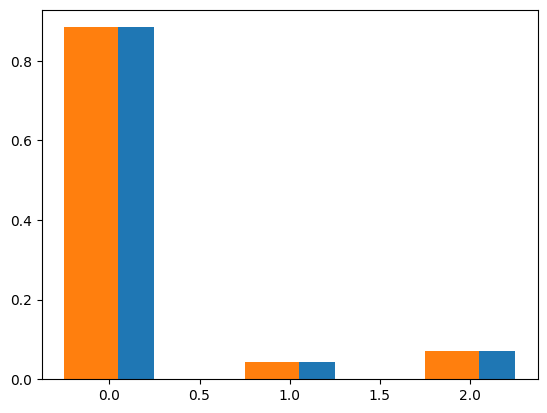

In [9]:
def proba_invariante2(P,N): 
    A=np.linalg.matrix_power(P,N)
    n=len(P)
    mu=np.ones(n)/n # on peut mettre ce que l'on veut comme loi initiale, ici je mets la loi uniforme
    return(mu.dot(A))

pi2=proba_invariante2(P_Grib,100)
print(pi2)

# on compare ce résultat à celui obtenu avec la méthode précédente 
E=np.arange(len(P_Grib))
plt.bar(E+0.1,pi1,width=0.3)
plt.bar(E-0.1,pi2,width=0.3)
plt.show()
# très bon résultat 

### 4.2.3) Troisième méthode : en utilisant le théorème ergodique 

Le théorème ergodique nous dit que si $P$ est irréductible et si la chaîne est réccurente positive (encore une fois, ce point découle de l'irréductibilité si l'on se place sur un espace d'états fini), alors pour toute loi initiale $\nu$ et pour toute fonction bornée $f$ sur l'espace d'états $E$, on a 
$$ \frac {1} {n} \sum_{k=1}^n f(X_k) \xrightarrow[n \to \infty]{\mathbb P _\nu \text{ p.s.}} \int_E f \mathrm{d} \pi, $$
où $\pi$ est l'unique proba invariante de la chaîne (qui, de nouveau, existe d'après le premier point). 
En particulier, on a pour tout état $i$ de $E$ et pour toute loi initiale $\nu$, 
$$ \frac{1}{n} \sum_{k=1}^{n} \mathbb{1}_{ \{ X_k=i \}}  \xrightarrow[n \to \infty]{\mathbb P _\nu \text{ p.s.}} \pi(i).$$
C'est de ce résultat dont on se sert pour fabriquer la troisième méthode de calcul de la proba invariante. (C'est intuitif : le vecteur des fréquences de passage converge vers la proba "stable".)

[0.8816 0.0428 0.0756]


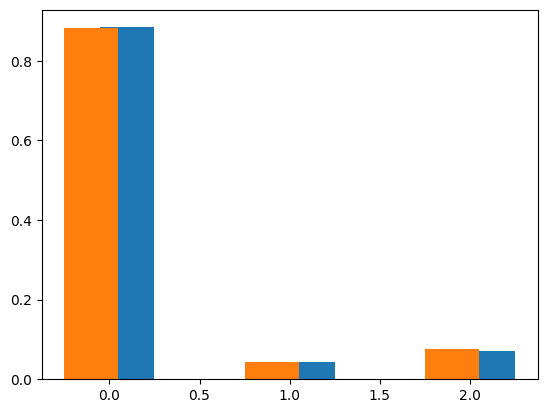

In [10]:
def proba_invariante3(n,P,x0): # ici, la loi initiale est le Dirac en x0, mais on aurait pu mettre n'importe quelle autre loi initiale
    X=trajectoire_Markov(n,P,x0)
    P=np.array([np.mean(X==i) for i in range (len(P))])
    return(P)

pi3=proba_invariante3(10000,P_Grib,0)
print(pi3)

# on compare ce résultat à celui obtenu avec la méthode précédente 
E=np.arange(len(P_Grib))
plt.bar(E+0.1,pi1,width=0.3)
plt.bar(E-0.1,pi3,width=0.3)
plt.show()
# un chouilla moins précis 